In [ ]:
# !pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.metrics            import (classification_report, confusion_matrix,
                                        roc_auc_score, roc_curve,
                                        precision_recall_curve, f1_score,
                                        accuracy_score, average_precision_score)
from xgboost                    import XGBClassifier
from lightgbm                   import LGBMClassifier
from imblearn.over_sampling     import SMOTE

c:\Users\LENOVO\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.color'       : 'white',
    'grid.linewidth'   : 1.2,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})
PALETTE   = ['#4361ee','#f72585','#4cc9f0','#7209b7','#fb8500','#2dc653']
HIT_COLOR = '#4361ee'
FLOP_COLOR = '#f72585'

In [4]:
# 1. LOAD, CLEAN & LABELING
df = pd.read_csv('../data/processed/tmdb_movies_clean_csv/tmdb_movies_clean.csv',
                 engine='python', on_bad_lines='skip')

# Numeric conversions
for col in ['Grossed in $','TMDB Rating','Votes','Duration','Popularity','Year']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean Certificate
valid_certs = ['G','PG','PG-13','R','NC-17','NR']
df['Certificate'] = df['Certificate'].where(df['Certificate'].isin(valid_certs), 'Unknown')

FILL_VAL = 21_760_713.0

# ── LABELING — Opsi 3 ─────────────────────────────────────────
# HIT  : grossed ≥ $50M  ATAU  TMDB Rating ≥ 7.5
# FLOP : grossed < $10M  DAN   TMDB Rating < 5.5
# Abu-abu (di antara keduanya) → dibuang agar model lebih tegas
def label_hit_flop(row):
    gross  = row['Grossed in $']
    rating = row['TMDB Rating']
    if pd.isna(gross) or gross == FILL_VAL or pd.isna(rating):
        return None
    if gross >= 50_000_000 or rating >= 7.5:
        return 'hit'
    elif gross < 10_000_000 and rating < 5.5:
        return 'flop'
    return None  # zona abu-abu → drop

df['label'] = df.apply(label_hit_flop, axis=1)

# Drop nulls & baris genre tidak valid
df = df.dropna(subset=['label','TMDB Rating','Votes','Duration',
                        'Popularity','Genre','Original Language','Year'])
df = df[df['Genre'].str.match(r'^[A-Za-z, /]+$', na=False)].reset_index(drop=True)

n_hit  = (df['label'] == 'hit').sum()
n_flop = (df['label'] == 'flop').sum()
print(f"  → Dataset: {len(df):,} film  |  hit={n_hit:,}  flop={n_flop:,}")
print(f"  → Imbalance ratio  1 : {n_hit // n_flop}  → akan ditangani SMOTE")


  → Dataset: 3,764 film  |  hit=3,616  flop=148
  → Imbalance ratio  1 : 24  → akan ditangani SMOTE


In [5]:
# 2. FEATURE ENGINEERING
MAIN_GENRES = ['Action','Adventure','Animation','Comedy','Crime',
               'Documentary','Drama','Family','Fantasy','History',
               'Horror','Music','Mystery','Romance','Science Fiction',
               'Thriller','War','Western']

for g in MAIN_GENRES:
    df[f'genre_{g.replace(" ","_")}'] = df['Genre'].apply(lambda x: 1 if g in str(x) else 0)

df['genre_count'] = df['Genre'].apply(lambda x: len(str(x).split(',')))

top_langs = df['Original Language'].value_counts().head(8).index.tolist()
for lang in top_langs:
    df[f'lang_{lang}'] = (df['Original Language'] == lang).astype(int)

cert_map = {'G':1,'PG':2,'PG-13':3,'R':4,'NC-17':5,'NR':3,'Unknown':3}
df['cert_num'] = df['Certificate'].map(cert_map)

df['log_votes']      = np.log1p(df['Votes'])
df['log_popularity'] = np.log1p(df['Popularity'])
df['year_norm']      = (df['Year'] - df['Year'].mean()) / df['Year'].std()
df['duration_sq']    = df['Duration'] ** 2

# CATATAN: TMDB Rating & Grossed in $ SENGAJA tidak dimasukkan sebagai fitur
# karena keduanya langsung mendefinisikan label hit/flop → data leakage!
# Fitur yang dipakai hanyalah yang bisa diketahui SEBELUM rilis / tanpa bias label.

genre_cols  = [f'genre_{g.replace(" ","_")}' for g in MAIN_GENRES] + ['genre_count']
lang_cols   = [f'lang_{l}' for l in top_langs]
num_cols    = ['log_votes','Duration','duration_sq',
               'log_popularity','cert_num','year_norm']
feature_cols = num_cols + genre_cols + lang_cols

X = df[feature_cols].values
y = LabelEncoder().fit_transform(df['label'])   # flop=0, hit=1

print(f"  → {len(feature_cols)} fitur  |  flop=0, hit=1")


  → 33 fitur  |  flop=0, hit=1


In [6]:
# 3. SPLIT → SMOTE → SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE hanya pada train set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"  → Train sebelum SMOTE : {np.bincount(y_train)}")
print(f"  → Train setelah SMOTE : {np.bincount(y_train_sm)} (balanced)")
print(f"  → Test  (asli)        : {np.bincount(y_test)}")

scaler       = StandardScaler()
X_train_s    = scaler.fit_transform(X_train_sm)
X_test_s     = scaler.transform(X_test)
X_train_tree = X_train_sm          # tree-based tidak perlu scaling
X_test_tree  = X_test

  → Train sebelum SMOTE : [ 118 2893]
  → Train setelah SMOTE : [2893 2893] (balanced)
  → Test  (asli)        : [ 30 723]


In [7]:
# 4. TRAIN SEMUA MODEL
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, C=1.0, random_state=42), True),
    'Decision Tree'      : (DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42), False),
    'K-Nearest Neighbor' : (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
    'Random Forest'      : (RandomForestClassifier(n_estimators=200, max_depth=12,
                                                    min_samples_leaf=3, random_state=42, n_jobs=-1), False),
    'XGBoost'            : (XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=6, subsample=0.8,
                                          colsample_bytree=0.8, random_state=42,
                                          verbosity=0, n_jobs=-1,
                                          eval_metric='logloss'), False),
    'LightGBM'           : (LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           max_depth=6, subsample=0.8,
                                           colsample_bytree=0.8, random_state=42,
                                           verbose=-1, n_jobs=-1), False),
}

results  = {}
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, use_scaled) in models.items():
    Xtr = X_train_s    if use_scaled else X_train_tree
    Xte = X_test_s     if use_scaled else X_test_tree

    model.fit(Xtr, y_train_sm)
    y_pred      = model.predict(Xte)
    y_prob      = model.predict_proba(Xte)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    f1_f = f1_score(y_test, y_pred, pos_label=0)   # f1 untuk kelas flop
    auc  = roc_auc_score(y_test, y_prob)
    ap   = average_precision_score(y_test, y_prob)

    # CV pada train (post-SMOTE)
    cv_f1 = cross_val_score(model, Xtr, y_train_sm,
                            cv=skf, scoring='f1_weighted', n_jobs=-1).mean()

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'accuracy' : acc,
        'f1_w'     : f1,
        'f1_flop'  : f1_f,
        'auc'      : auc,
        'ap'       : ap,
        'cv_f1'    : cv_f1,
        'use_scaled': use_scaled,
    }
    print(f"  {name:<22} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  F1-flop={f1_f:.4f}")

# Best model: prioritas AUC karena class imbalance
best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n  ★ Model terbaik : {best_name}  (AUC={results[best_name]['auc']:.4f})")


  Logistic Regression    Acc=0.9442  F1=0.9529  AUC=0.9288  F1-flop=0.5333
  Decision Tree          Acc=0.9509  F1=0.9539  AUC=0.8553  F1-flop=0.4638
  K-Nearest Neighbor     Acc=0.9150  F1=0.9303  AUC=0.7501  F1-flop=0.3469
  Random Forest          Acc=0.9681  F1=0.9643  AUC=0.9692  F1-flop=0.5000
  XGBoost                Acc=0.9761  F1=0.9753  AUC=0.9810  F1-flop=0.6786
  LightGBM               Acc=0.9708  F1=0.9692  AUC=0.9783  F1-flop=0.5926

  ★ Model terbaik : XGBoost  (AUC=0.9810)


In [8]:
%matplotlib inline

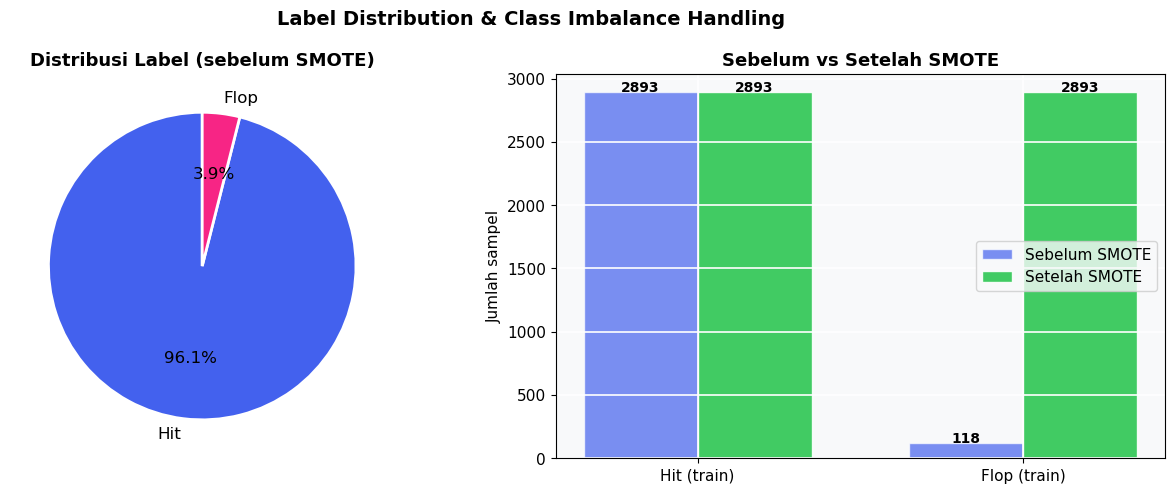

In [9]:
# 5. VISUALISASI
# ── Fig 1: Label distribution + Class imbalance ───────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle('Label Distribution & Class Imbalance Handling',
              fontsize=14, fontweight='bold')

# Pie chart label
label_counts = df['label'].value_counts()
axes1[0].pie(label_counts, labels=['Hit','Flop'],
             colors=[HIT_COLOR, FLOP_COLOR],
             autopct='%1.1f%%', startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2},
             textprops={'fontsize':12})
axes1[0].set_title('Distribusi Label (sebelum SMOTE)')

# Before vs after SMOTE
categories = ['Hit (train)', 'Flop (train)']
before = [np.bincount(y_train)[1], np.bincount(y_train)[0]]
after  = [np.bincount(y_train_sm)[1], np.bincount(y_train_sm)[0]]
x = np.arange(len(categories))
w = 0.35
axes1[1].bar(x - w/2, before, w, label='Sebelum SMOTE', color=HIT_COLOR, alpha=0.7, edgecolor='white')
axes1[1].bar(x + w/2, after,  w, label='Setelah SMOTE',  color='#2dc653', alpha=0.9, edgecolor='white')
for i, (b, a) in enumerate(zip(before, after)):
    axes1[1].text(i - w/2, b + 5, str(b), ha='center', fontsize=10, fontweight='bold')
    axes1[1].text(i + w/2, a + 5, str(a), ha='center', fontsize=10, fontweight='bold')
axes1[1].set_xticks(x)
axes1[1].set_xticklabels(categories)
axes1[1].set_title('Sebelum vs Setelah SMOTE')
axes1[1].set_ylabel('Jumlah sampel')
axes1[1].legend()

plt.tight_layout()
plt.show()

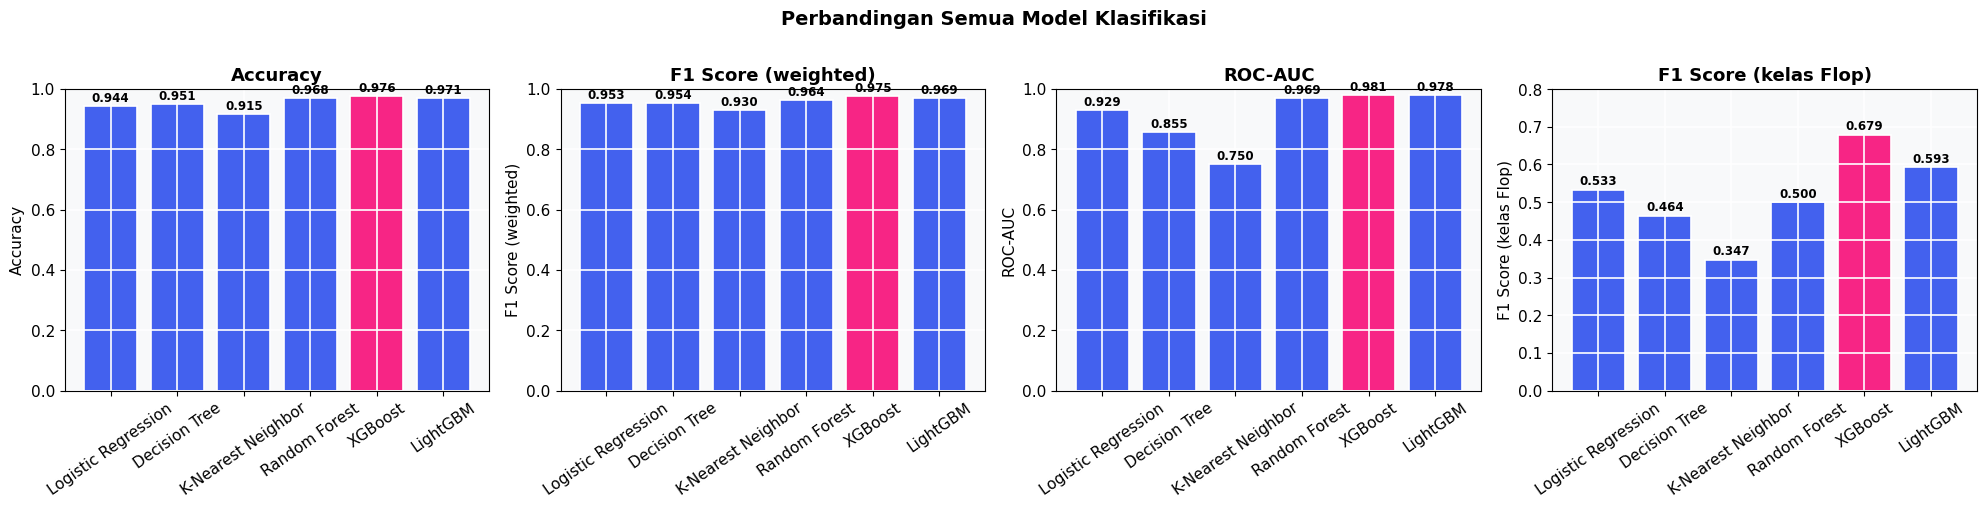

In [10]:
# ── Fig 2: Model comparison bar chart ─────────────────────────
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
fig2.suptitle('Perbandingan Semua Model Klasifikasi',
              fontsize=14, fontweight='bold', y=1.01)

metrics = [
    ('accuracy', 'Accuracy'),
    ('f1_w',     'F1 Score (weighted)'),
    ('auc',      'ROC-AUC'),
    ('f1_flop',  'F1 Score (kelas Flop)'),
]
names = list(results.keys())

for ax, (metric, label) in zip(axes2, metrics):
    vals   = [results[n][metric] for n in names]
    colors = [('#f72585' if n == best_name else '#4361ee') for n in names]
    bars   = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_title(label)
    ax.set_ylim(0, min(1.0, max(vals) * 1.18))
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

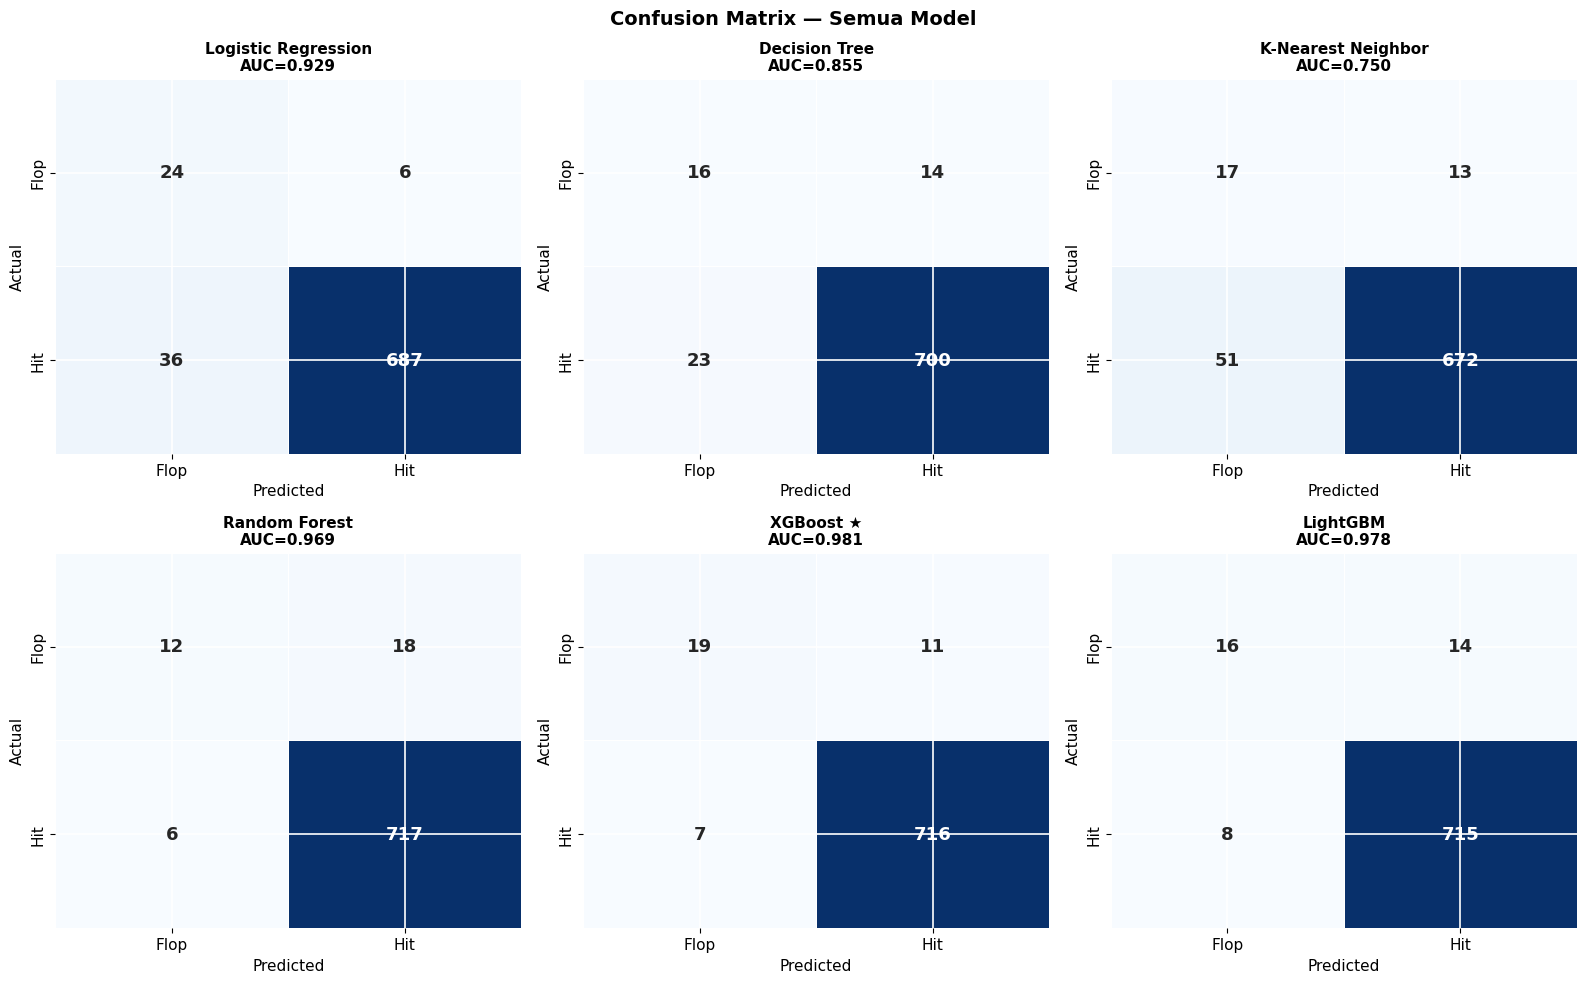

In [11]:
# ── Fig 3: Confusion matrices semua model ─────────────────────
n_models = len(results)
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 10))
fig3.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')
axes3 = axes3.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Flop','Hit'], yticklabels=['Flop','Hit'],
                ax=axes3[i], linewidths=0.5, linecolor='white',
                annot_kws={'size':13, 'weight':'bold'},
                cbar=False)
    auc_str = f"AUC={r['auc']:.3f}"
    marker  = ' ★' if name == best_name else ''
    axes3[i].set_title(f'{name}{marker}\n{auc_str}', fontsize=11)
    axes3[i].set_xlabel('Predicted')
    axes3[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

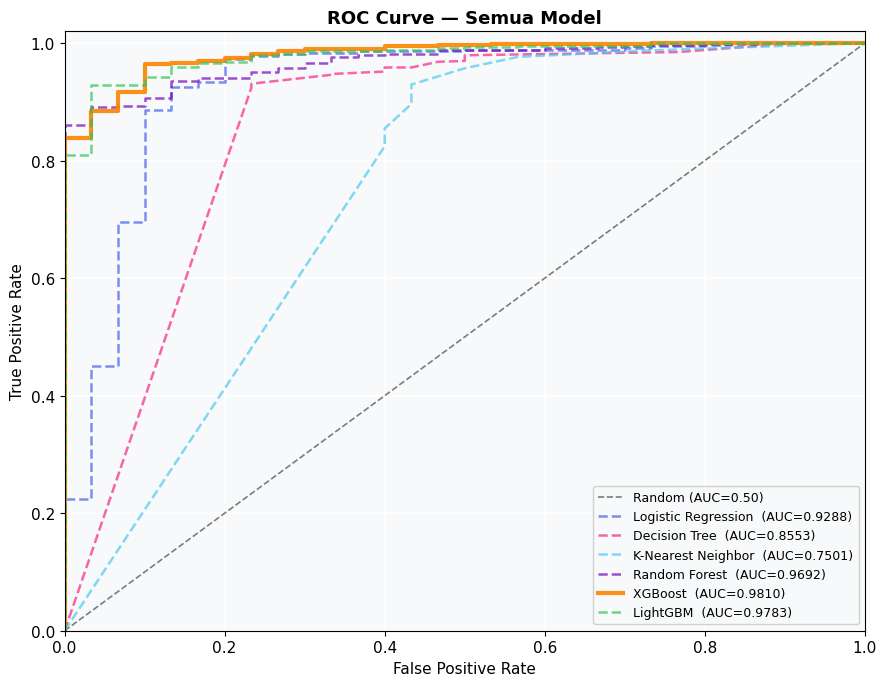

In [12]:
# ── Fig 4: ROC Curve semua model ──────────────────────────────
fig4, ax4 = plt.subplots(figsize=(9, 7))
ax4.plot([0,1],[0,1],'k--', linewidth=1.2, alpha=0.5, label='Random (AUC=0.50)')

for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    lw = 3.0 if name == best_name else 1.8
    ls = '-'  if name == best_name else '--'
    ax4.plot(fpr, tpr, linewidth=lw, linestyle=ls,
             color=PALETTE[i % len(PALETTE)],
             label=f'{name}  (AUC={r["auc"]:.4f})',
             alpha=0.9 if name == best_name else 0.7)

ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve — Semua Model')
ax4.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

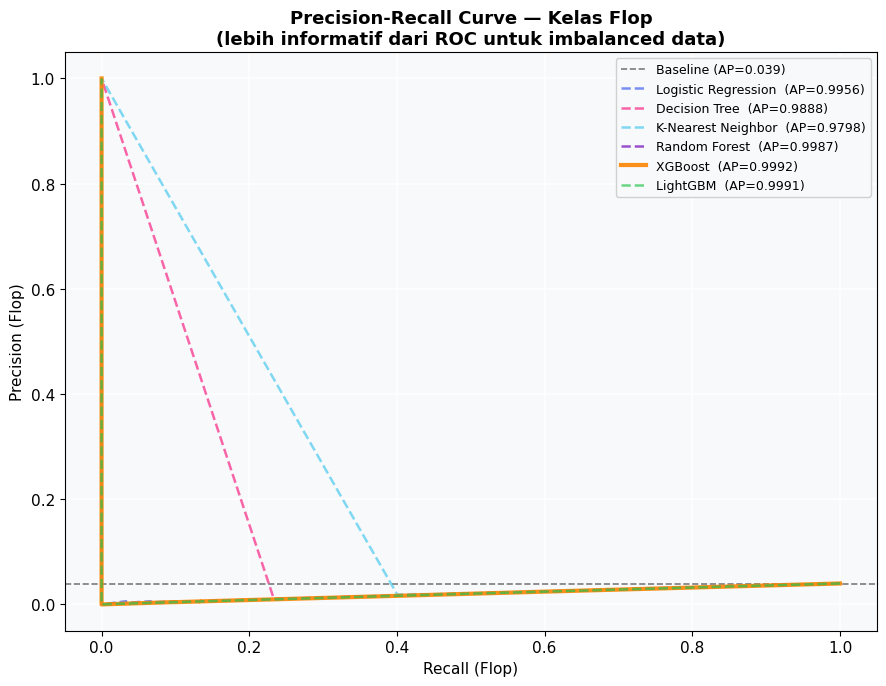

In [13]:
# ── Fig 5: Precision-Recall Curve (penting untuk imbalanced) ──
fig5, ax5 = plt.subplots(figsize=(9, 7))
baseline = n_flop / (n_hit + n_flop)
ax5.axhline(baseline, color='k', linestyle='--', linewidth=1.2,
            alpha=0.5, label=f'Baseline (AP={baseline:.3f})')

for i, (name, r) in enumerate(results.items()):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'], pos_label=0)
    lw = 3.0 if name == best_name else 1.8
    ls = '-'  if name == best_name else '--'
    ax5.plot(rec, prec, linewidth=lw, linestyle=ls,
             color=PALETTE[i % len(PALETTE)],
             label=f'{name}  (AP={r["ap"]:.4f})',
             alpha=0.9 if name == best_name else 0.7)

ax5.set_xlabel('Recall (Flop)')
ax5.set_ylabel('Precision (Flop)')
ax5.set_title('Precision-Recall Curve — Kelas Flop\n(lebih informatif dari ROC untuk imbalanced data)')
ax5.legend(fontsize=9, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

  → SHAP berhasil


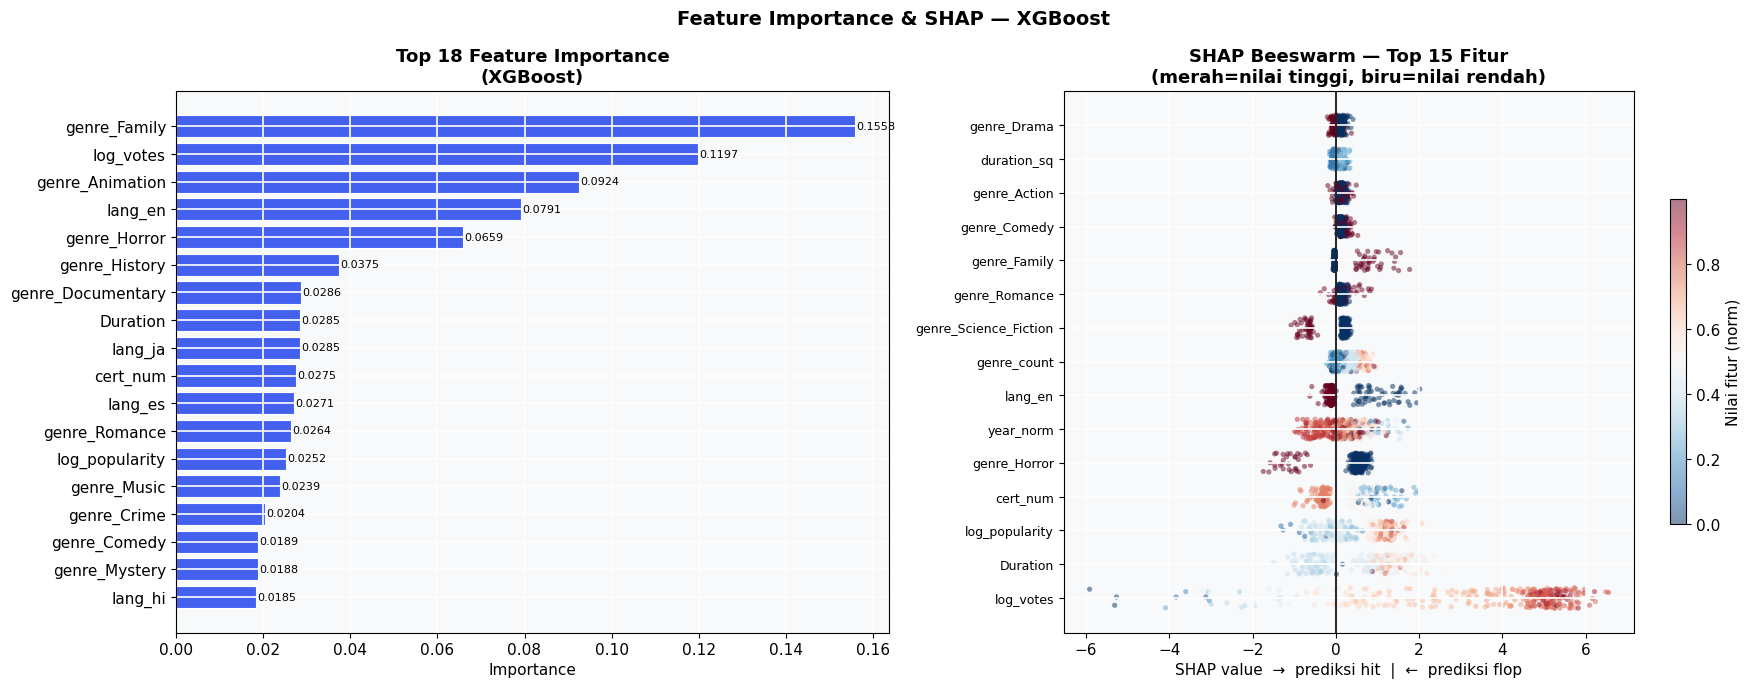

In [14]:
# ── Fig 6: Feature Importance + SHAP ─────────────────────────
tree_models = {k: v for k, v in results.items()
               if k not in ('Logistic Regression','K-Nearest Neighbor')}
best_tree_name = max(tree_models, key=lambda k: tree_models[k]['auc'])
best_tree_model = results[best_tree_name]['model']

fig6, axes6 = plt.subplots(1, 2, figsize=(18, 7))
fig6.suptitle(f'Feature Importance & SHAP — {best_tree_name}',
              fontsize=14, fontweight='bold')

# Feature importance bar
if hasattr(best_tree_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature'   : feature_cols,
        'importance': best_tree_model.feature_importances_,
    }).sort_values('importance', ascending=False).head(18)

    axes6[0].barh(fi['feature'][::-1], fi['importance'][::-1],
                  color='#4361ee', edgecolor='white', linewidth=0.8)
    axes6[0].set_title(f'Top 18 Feature Importance\n({best_tree_name})')
    axes6[0].set_xlabel('Importance')
    for i, (_, row) in enumerate(fi[::-1].iterrows()):
        axes6[0].text(row['importance'] + 0.0003, i,
                      f'{row["importance"]:.4f}', va='center', fontsize=8)

# SHAP
try:
    Xte_tree = X_test_tree
    sample_idx = np.random.choice(len(Xte_tree), min(300, len(Xte_tree)), replace=False)
    X_shap = Xte_tree[sample_idx]

    explainer = shap.TreeExplainer(best_tree_model)
    shap_vals = explainer.shap_values(X_shap)

    # Untuk binary: ambil SHAP untuk kelas hit (index 1)
    if isinstance(shap_vals, list):
        sv = shap_vals[1]
    else:
        sv = shap_vals

    mean_abs = np.abs(sv).mean(axis=0)
    shap_df  = pd.DataFrame({
        'feature'      : feature_cols,
        'mean_abs_shap': mean_abs,
    }).sort_values('mean_abs_shap', ascending=False).head(15)

    top_feats   = shap_df['feature'].tolist()
    top_indices = [feature_cols.index(f) for f in top_feats]

    for i, (fidx, fname) in enumerate(zip(top_indices, top_feats)):
        shap_col = sv[:, fidx]
        feat_col = X_shap[:, fidx]
        vmin, vmax = feat_col.min(), feat_col.max()
        norm_feat  = (feat_col - vmin) / (vmax - vmin + 1e-8)
        jitter = np.random.uniform(-0.3, 0.3, len(shap_col))
        sc = axes6[1].scatter(
            shap_col, np.full_like(shap_col, i) + jitter,
            c=norm_feat, cmap='RdBu_r', alpha=0.5, s=14, linewidths=0)

    axes6[1].set_yticks(range(len(top_feats)))
    axes6[1].set_yticklabels(top_feats, fontsize=9)
    axes6[1].axvline(0, color='black', linewidth=1.2)
    axes6[1].set_xlabel('SHAP value  →  prediksi hit  |  ←  prediksi flop')
    axes6[1].set_title('SHAP Beeswarm — Top 15 Fitur\n(merah=nilai tinggi, biru=nilai rendah)')
    plt.colorbar(sc, ax=axes6[1], label='Nilai fitur (norm)', shrink=0.6)
    print("  → SHAP berhasil")
except Exception as e:
    axes6[1].text(0.5, 0.5, f'SHAP error:\n{e}', ha='center', va='center',
                  transform=axes6[1].transAxes, fontsize=10, color='red')
    print(f"  SHAP error: {e}")

plt.tight_layout()
plt.show()

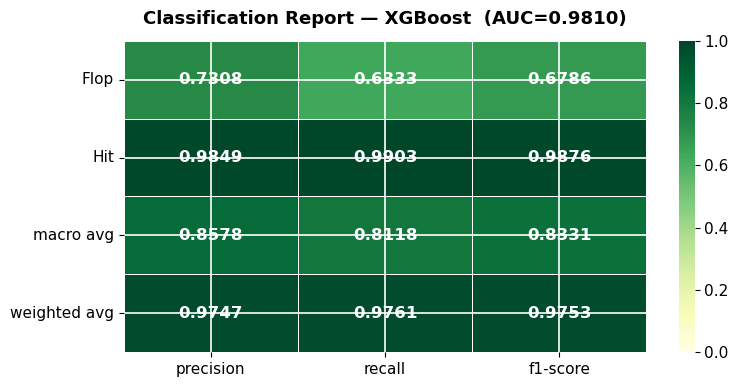

In [15]:
# ── Fig 7: Classification report heatmap (best model) ─────────
report = classification_report(y_test, results[best_name]['y_pred'],
                                target_names=['Flop','Hit'], output_dict=True)
report_df = pd.DataFrame(report).T.drop('accuracy', errors='ignore')
report_df = report_df[['precision','recall','f1-score','support']].astype(float)

fig7, ax7 = plt.subplots(figsize=(8, 4))
sns.heatmap(report_df[['precision','recall','f1-score']],
            annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            ax=ax7, vmin=0, vmax=1,
            annot_kws={'size':12, 'weight':'bold'})
ax7.set_title(f'Classification Report — {best_name}  (AUC={results[best_name]["auc"]:.4f})',
              fontsize=13, fontweight='bold', pad=12)
ax7.set_ylabel('')
plt.tight_layout()
plt.show()

In [16]:
# 6. RINGKASAN AKHIR
print("\n" + "=" * 65)
print("  HASIL EVALUASI SEMUA MODEL")
print("=" * 65)
print(f"  {'Model':<22} {'Acc':>7} {'F1-w':>7} {'AUC':>7} {'F1-flop':>8}  {'CV-F1':>7}")
print(f"  {'-'*62}")
for name, r in sorted(results.items(), key=lambda x: -x[1]['auc']):
    mark = ' ★' if name == best_name else '  '
    print(f"{mark} {name:<22} {r['accuracy']:>7.4f} {r['f1_w']:>7.4f} "
          f"{r['auc']:>7.4f} {r['f1_flop']:>8.4f}  {r['cv_f1']:>7.4f}")

print(f"\n  Best model : {best_name}")
print(f"  Accuracy   : {results[best_name]['accuracy']:.4f}")
print(f"  F1-weighted: {results[best_name]['f1_w']:.4f}")
print(f"  ROC-AUC    : {results[best_name]['auc']:.4f}")
print(f"  F1-flop    : {results[best_name]['f1_flop']:.4f}")

print("\n" + "─" * 65)
print("  CATATAN METODOLOGI (untuk laporan/presentasi)")
print("─" * 65)
print(f"  • Label dibuat manual: hit = gross≥$50M OR rating≥7.5")
print(f"                         flop = gross<$10M AND rating<5.5")
print(f"  • Zona abu-abu di-drop → model lebih tegas")
print(f"  • Imbalance 1:{n_hit//n_flop} ditangani SMOTE pada train set saja")
print(f"  • Evaluasi utama: AUC & F1-flop (bukan accuracy)")
print(f"  • Accuracy tinggi bisa menipu karena 96% data adalah hit")



  HASIL EVALUASI SEMUA MODEL
  Model                      Acc    F1-w     AUC  F1-flop    CV-F1
  --------------------------------------------------------------
 ★ XGBoost                 0.9761  0.9753  0.9810   0.6786   0.9908
   LightGBM                0.9708  0.9692  0.9783   0.5926   0.9896
   Random Forest           0.9681  0.9643  0.9692   0.5000   0.9870
   Logistic Regression     0.9442  0.9529  0.9288   0.5333   0.9516
   Decision Tree           0.9509  0.9539  0.8553   0.4638   0.9627
   K-Nearest Neighbor      0.9150  0.9303  0.7501   0.3469   0.9539

  Best model : XGBoost
  Accuracy   : 0.9761
  F1-weighted: 0.9753
  ROC-AUC    : 0.9810
  F1-flop    : 0.6786

─────────────────────────────────────────────────────────────────
  CATATAN METODOLOGI (untuk laporan/presentasi)
─────────────────────────────────────────────────────────────────
  • Label dibuat manual: hit = gross≥$50M OR rating≥7.5
                         flop = gross<$10M AND rating<5.5
  • Zona abu-abu di-dro

In [17]:
# 7. FUNGSI PREDIKSI FILM BARU
print("\n" + "─" * 65)
print("  CONTOH PREDIKSI")
print("─" * 65)

best_model    = results[best_name]['model']
use_scaled_bm = results[best_name]['use_scaled']

def predict_hit_flop(movie_info: dict) -> dict:
    row = np.zeros(len(feature_cols))
    ci  = {c: i for i, c in enumerate(feature_cols)}

    row[ci['log_votes']]      = np.log1p(movie_info.get('votes', 1000))
    row[ci['Duration']]       = movie_info.get('duration', 110)
    row[ci['duration_sq']]    = movie_info.get('duration', 110) ** 2
    row[ci['log_popularity']] = np.log1p(movie_info.get('popularity', 5))
    row[ci['cert_num']]       = cert_map.get(movie_info.get('certificate','PG-13'), 3)
    row[ci['year_norm']]      = (movie_info.get('year', 2025) - df['Year'].mean()) / df['Year'].std()

    for g in movie_info.get('genres', []):
        key = f'genre_{g.replace(" ","_")}'
        if key in ci: row[ci[key]] = 1
    row[ci['genre_count']] = len(movie_info.get('genres', []))

    lang_key = f'lang_{movie_info.get("language","en")}'
    if lang_key in ci: row[ci[lang_key]] = 1

    X_input = row.reshape(1, -1)
    if use_scaled_bm:
        X_input = scaler.transform(X_input)

    pred  = best_model.predict(X_input)[0]
    prob  = best_model.predict_proba(X_input)[0]
    label = 'HIT ✓' if pred == 1 else 'FLOP ✗'
    return {'label': label, 'prob_hit': prob[1], 'prob_flop': prob[0]}

sample_movies = [
    dict(name='Marvel-style blockbuster', votes=50000,
         duration=150, popularity=80,
         year=2025, certificate='PG-13', genres=['Action','Adventure','Science Fiction'], language='en'),
    dict(name='Indie arthouse drama',     votes=2000,
         duration=95,  popularity=4,
         year=2024, certificate='R',    genres=['Drama'], language='fr'),
    dict(name='Low-budget horror',        votes=150,
         duration=85,  popularity=1,
         year=2023, certificate='R',    genres=['Horror','Thriller'], language='en'),
    dict(name='Anime blockbuster',        votes=15000,
         duration=125, popularity=35,
         year=2025, certificate='PG',   genres=['Animation','Fantasy','Adventure'], language='ja'),
    dict(name='Mediocre action sequel',   votes=8000,
         duration=120, popularity=20,
         year=2024, certificate='PG-13', genres=['Action','Thriller'], language='en'),
]

for m in sample_movies:
    res_p = predict_hit_flop(m)
    print(f"  {m['name']:<35} → {res_p['label']}  "
          f"(P_hit={res_p['prob_hit']:.3f} | P_flop={res_p['prob_flop']:.3f})")



─────────────────────────────────────────────────────────────────
  CONTOH PREDIKSI
─────────────────────────────────────────────────────────────────
  Marvel-style blockbuster            → HIT ✓  (P_hit=1.000 | P_flop=0.000)
  Indie arthouse drama                → HIT ✓  (P_hit=0.991 | P_flop=0.009)
  Low-budget horror                   → FLOP ✗  (P_hit=0.001 | P_flop=0.999)
  Anime blockbuster                   → HIT ✓  (P_hit=1.000 | P_flop=0.000)
  Mediocre action sequel              → HIT ✓  (P_hit=1.000 | P_flop=0.000)
